In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. 加载数据
df = pd.read_csv('G:/xiangmu/user_personalized_features.csv')  # 根据实际路径修改

print("数据预览：")
display(df.head())

print("\n数据基础信息：")
df.info()

print("\n数值字段统计描述：")
display(df.describe())


数据预览：


,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True



数据基础信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   1000 non-null   int64 
 1   User_ID                      1000 non-null   object
 2   Age                          1000 non-null   int64 
 3   Gender                       1000 non-null   object
 4   Location                     1000 non-null   object
 5   Income                       1000 non-null   int64 
 6   Interests                    1000 non-null   object
 7   Last_Login_Days_Ago          1000 non-null   int64 
 8   Purchase_Frequency           1000 non-null   int64 
 9   Average_Order_Value          1000 non-null   int64 
 10  Total_Spending               1000 non-null   int64 
 11  Product_Category_Preference  1000 non-null   object
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 13  Pages_Viewed             

,Unnamed: 0,Age,Income,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Time_Spent_on_Site_Minutes,Pages_Viewed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,499.500000,40.986000,81304.732000,15.586000,4.631000,104.039000,2552.957000,297.360000,24.40300
std,288.819436,13.497852,37363.972753,8.205604,2.837762,54.873569,1420.985048,175.596123,14.02017
min,0.000000,18.000000,20155.000000,1.000000,0.000000,10.000000,112.000000,2.000000,1.00000
25%,249.750000,29.000000,48715.500000,8.000000,2.000000,58.000000,1271.750000,144.000000,12.00000
50%,499.500000,42.000000,81042.000000,16.000000,5.000000,105.000000,2542.000000,292.500000,24.50000
75%,749.250000,52.000000,112694.500000,23.000000,7.000000,150.000000,3835.500000,449.250000,36.00000
max,999.000000,64.000000,149951.000000,29.000000,9.000000,199.000000,4999.000000,599.000000,49.00000


流失比例：
Is_Churn
0    0.67
1    0.33
Name: proportion, dtype: float64


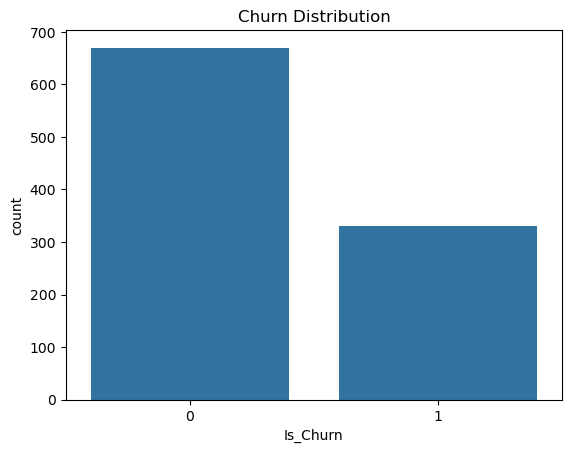

编码后的数据预览：


,Age,Gender,Income,Purchase_Frequency,Average_Order_Value,Total_Spending,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription,Is_Churn,Location_Suburban,Location_Urban,Interests_Food,Interests_Sports,Interests_Technology,Interests_Travel,Product_Category_Preference_Books,Product_Category_Preference_Electronics,Product_Category_Preference_Health & Beauty,Product_Category_Preference_Home & Kitchen
0,56,1,38037,7,18,2546,584,38,1,0,True,False,False,True,False,False,True,False,False,False
1,46,0,103986,7,118,320,432,40,0,0,False,False,False,False,True,False,False,True,False,False
2,32,0,101942,1,146,3766,306,1,1,1,True,False,False,True,False,False,False,False,False,False
3,60,0,71612,3,163,4377,527,29,0,0,True,False,False,False,False,False,False,False,False,False
4,25,1,49725,5,141,4502,53,10,1,0,True,False,False,False,False,True,False,False,True,False


In [6]:
# 2. 特征工程

# 2.1 构建流失标签 Is_Churn
# 业务规则：如果用户最后登录天数超过20天，定义为流失
threshold = 20 
df['Is_Churn'] = (df['Last_Login_Days_Ago'] > threshold).astype(int)

print("流失比例：")
print(df['Is_Churn'].value_counts(normalize=True))

# 可视化流失分布
sns.countplot(x='Is_Churn', data=df)
plt.title('Churn Distribution')
plt.show()

# 2.2 特征编码
# 将布尔值转为 0/1
df['Newsletter_Subscription'] = df['Newsletter_Subscription'].astype(int)

# 性别映射
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# 对分类特征进行独热编码（drop_first 避免多重共线性）
df_encoded = pd.get_dummies(df, columns=['Location', 'Interests', 'Product_Category_Preference'], drop_first=True)

# 删除无关列和用于生成标签的原始列
cols_to_drop = ['Unnamed: 0', 'User_ID', 'Last_Login_Days_Ago']
df_final = df_encoded.drop(columns=cols_to_drop, errors='ignore')  # errors='ignore' 避免某些列不存在时报错

print("编码后的数据预览：")
display(df_final.head())

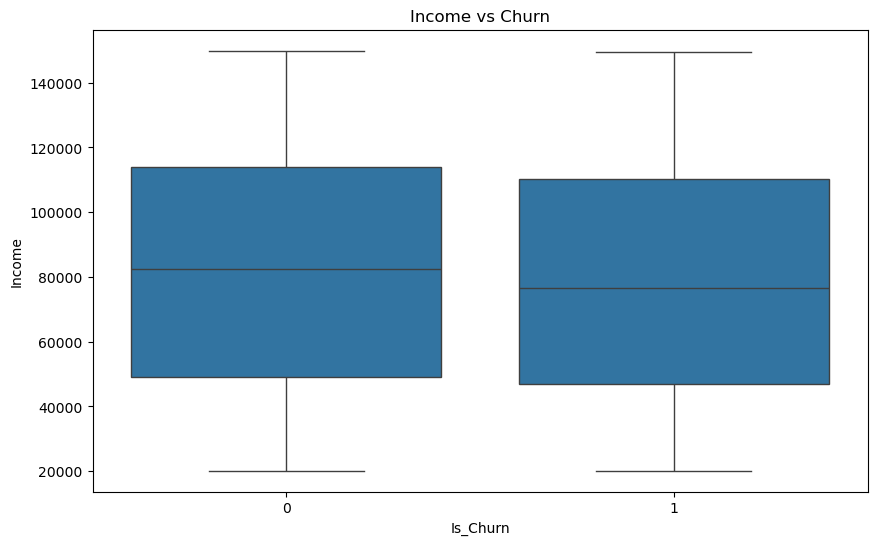


订阅邮件与流失的关系矩阵（行百分比）：
Is_Churn                        0         1
Newsletter_Subscription                    
0                        0.657201  0.342799
1                        0.682446  0.317554

各特征与流失的相关性：
Is_Churn                                       1.000000
Product_Category_Preference_Home & Kitchen     0.057743
Age                                            0.049911
Total_Spending                                 0.046849
Purchase_Frequency                             0.044066
Location_Suburban                              0.039397
Gender                                         0.035862
Interests_Technology                           0.025251
Average_Order_Value                            0.014081
Interests_Sports                               0.008882
Interests_Travel                               0.007072
Location_Urban                                -0.002328
Interests_Food                                -0.009000
Product_Category_Preference_Health & Beauty   -0.013008
Produc

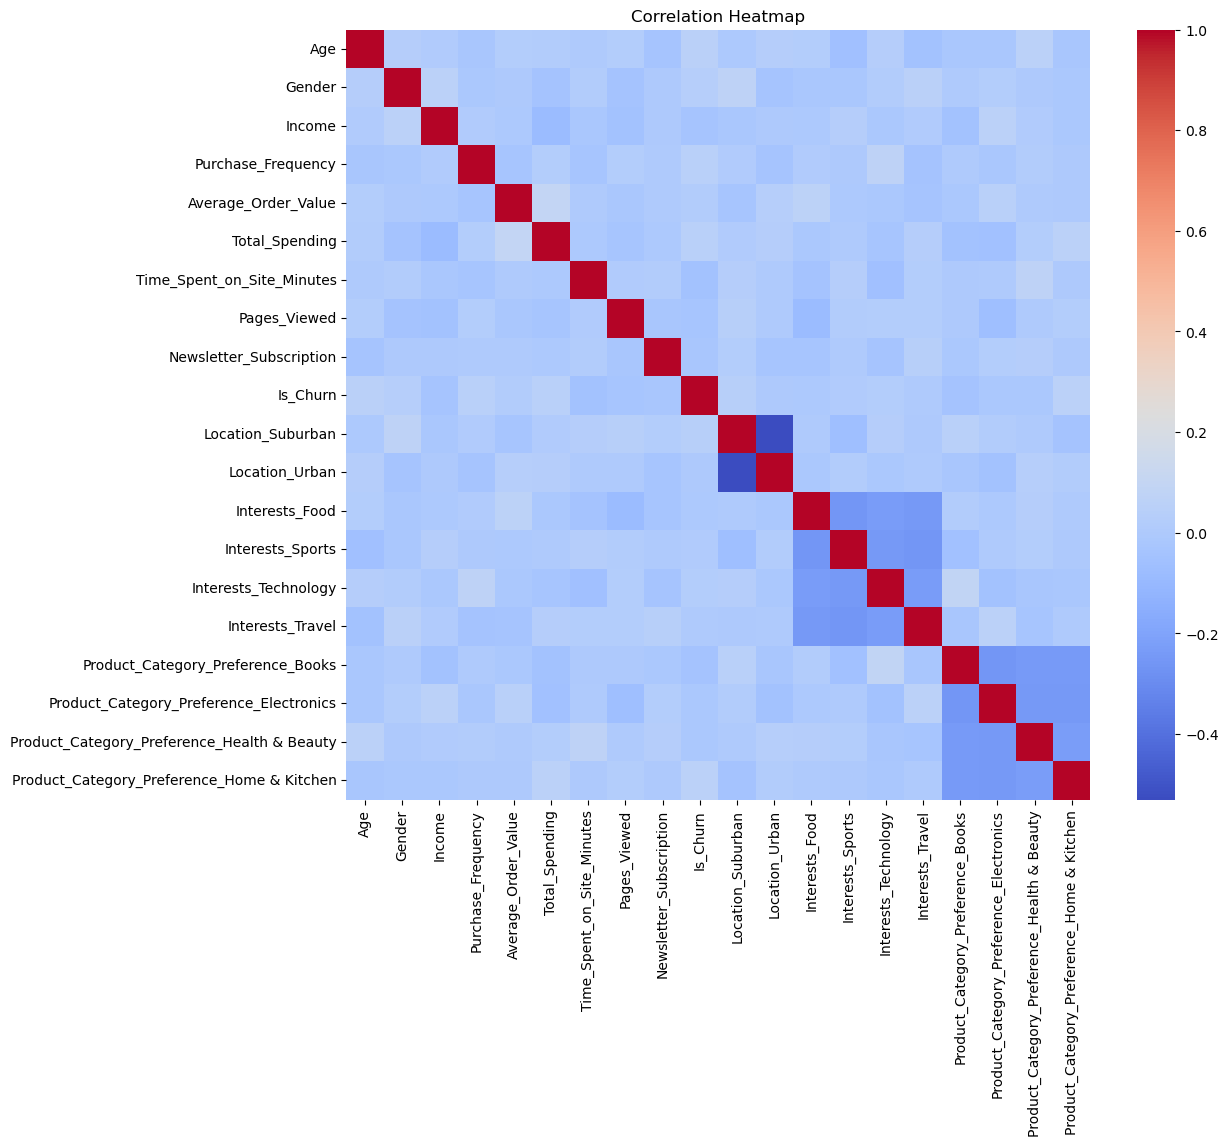

In [7]:
# 3. 探索性数据分析（EDA）

# 3.1 观察收入与流失的关系
plt.figure(figsize=(10, 6))
sns.boxplot(x='Is_Churn', y='Income', data=df)
plt.title('Income vs Churn')
plt.show()

# 3.2 订阅邮件与流失的关系（业务价值）
pivot_table = pd.crosstab(df['Newsletter_Subscription'], df['Is_Churn'], normalize='index')
print("\n订阅邮件与流失的关系矩阵（行百分比）：")
print(pivot_table)

# 3.3 特征与流失的相关性
plt.figure(figsize=(12, 10))
corr_matrix = df_final.corr()

# 只看与 Is_Churn 的相关性排序
churn_corr = corr_matrix['Is_Churn'].sort_values(ascending=False)
print("\n各特征与流失的相关性：")
print(churn_corr)

# 热力图
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


逻辑回归评估结果
混淆矩阵：
[[141   2]
 [ 54   3]]

分类报告：
              precision    recall  f1-score   support

           0       0.72      0.99      0.83       143
           1       0.60      0.05      0.10        57

    accuracy                           0.72       200
   macro avg       0.66      0.52      0.47       200
weighted avg       0.69      0.72      0.62       200

ROC-AUC 分数：0.5167

随机森林评估结果
混淆矩阵：
[[138   5]
 [ 55   2]]

分类报告：
              precision    recall  f1-score   support

           0       0.72      0.97      0.82       143
           1       0.29      0.04      0.06        57

    accuracy                           0.70       200
   macro avg       0.50      0.50      0.44       200
weighted avg       0.59      0.70      0.61       200

ROC-AUC 分数：0.5409


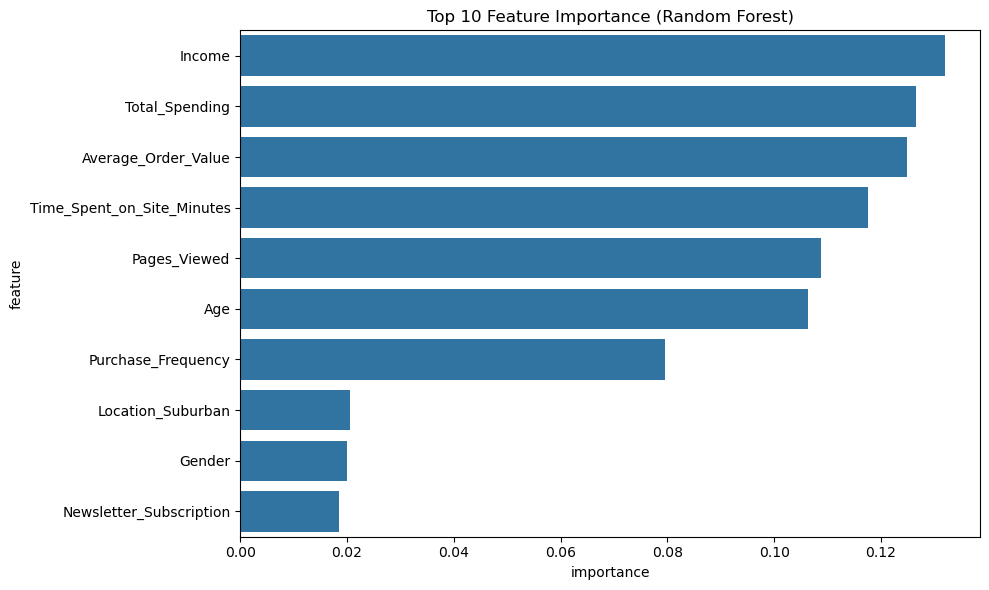

In [8]:
# 4. 建模与评估

# 准备特征矩阵 X 和目标向量 y
X = df_final.drop('Is_Churn', axis=1)
y = df_final['Is_Churn']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.1 逻辑回归（需要标准化）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n逻辑回归评估结果")
print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred_lr))
print("\n分类报告：")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC 分数：{roc_auc_score(y_test, y_prob_lr):.4f}")

# 4.2 随机森林（无需标准化，自带特征重要性）
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n随机森林评估结果")
print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred_rf))
print("\n分类报告：")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC 分数：{roc_auc_score(y_test, y_prob_rf):.4f}")

# 4.3 特征重要性（随机森林）
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(10))
plt.title('Top 10 Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

In [ ]:
# 5. 总结

# 根据模型结果，可以得出以下结论：
# 1. 特征重要性最高的前几位是 收入，总支出，平均订单价值
# 2. 随机森林的 AUC 达到 0.5409 ，说明模型不能较好地区分流失与留存用户。原因可能有特征与标签的弱相关性，只有1000条数据，数据量不足等